In [1]:
## Load libraries
import pandas as pd
import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from keras.datasets import mnist
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
plt.style.use('dark_background')
%matplotlib inline

In [2]:
np.set_printoptions(precision=2)

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [4]:
tf.__version__

'2.14.0'

---

Mount Google Drive if running in Colab

---

In [5]:
## Mount Google drive folder if running in Colab
if('google.colab' in sys.modules):
    from google.colab import drive
    drive.mount('/content/drive', force_remount = True)
    DIR = '/content/drive/MyDrive/Colab Notebooks/MAHE/MSIS Coursework/EvenSem2024MAHE'
    DATA_DIR = DIR + '/Data/'
    os.chdir(DIR)
else:
    DATA_DIR = 'Data/'

---

Load diabetes data

---

In [7]:
## Load diabetes data
file = DATA_DIR+'diabetes_regression1.csv'
df= pd.read_csv(file, header = 0)

print('Diabetes dataset')
print('-----------')
print('Initial number of samples = %d'%(df.shape[0]))
print('Initial number of features = %d\n'%(df.shape[1]))
df.head(5)

Diabetes dataset
-----------
Initial number of samples = 442
Initial number of features = 11



,AGE,GENDER,BMI,BP,S1,S2,S3,S4,S5,S6,Y
0,59,2,32.1,101.0,157,93.2,38.0,4.0,4.8598,87,151
1,48,1,21.6,87.0,183,103.2,70.0,3.0,3.8918,69,75
2,72,2,30.5,93.0,156,93.6,41.0,4.0,4.6728,85,141
3,24,1,25.3,84.0,198,131.4,40.0,5.0,4.8903,89,206
4,50,1,23.0,101.0,192,125.4,52.0,4.0,4.2905,80,135


In [8]:
## Create lists of ordinal, categorical, and continuous features
#categorical_features =  ['GENDER', 'BMILEVEL']
categorical_features =  ['GENDER']
continuous_features = df.drop(categorical_features, axis = 1).columns.tolist()
print(categorical_features)
print(continuous_features)

['GENDER']
['AGE', 'BMI', 'BP', 'S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'Y']


---

Assign 'category' datatype to categorical columns

---

In [9]:
## Assign 'category' datatype to ordinal and categorical columns
print(df.dtypes)
df[categorical_features] = df[categorical_features].astype('category')
print('----')
df.dtypes

AGE         int64
GENDER      int64
BMI       float64
BP        float64
S1          int64
S2        float64
S3        float64
S4        float64
S5        float64
S6          int64
Y           int64
dtype: object
----


AGE          int64
GENDER    category
BMI        float64
BP         float64
S1           int64
S2         float64
S3         float64
S4         float64
S5         float64
S6           int64
Y            int64
dtype: object

---

Remove the target variable column from the list of continuous features

---

In [10]:
## Remove the target variable column from the list of continuous features
continuous_features.remove('Y')

In [11]:
## Train and test split of the data
X = df.drop('Y', axis = 1)
y = df['Y']
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

num_features = X_train.shape[0]
num_samples = X_train.shape[1]

print('Diabetes data set')
print('---------------------')
print('Number of training samples = %d'%(num_samples))
print('Number of features = %d'%(num_features))

Diabetes data set
---------------------
Number of training samples = 10
Number of features = 353


---

Build pipeline for categorical and continuous features

---

In [12]:
## Build pipeline for categorical and continuous features

# Pipeline object for categorical (features
categorical_transformer = Pipeline(steps = [('onehotenc', OneHotEncoder(handle_unknown = 'ignore'))])

# Pipeline object for continuous features
continuous_transformer = Pipeline(steps = [('scaler', RobustScaler())])

# Create a preprocessor object for all features
preprocessor = ColumnTransformer(transformers = [('continuous', continuous_transformer, continuous_features),
                                                 ('categorical', categorical_transformer, categorical_features)
                                                ],
                                 remainder = 'passthrough'
                                 )

---

Fit and transform train data using preprocessor followed by transforming test data

---

In [13]:
## Fit and transform train data using preprocessor
X_train_transformed = preprocessor.fit_transform(X_train).T
# Update number of features
num_features = X_train_transformed.shape[0]
# Transform training data using preprocessor
X_test_transformed = preprocessor.transform(X_test).T
# Convert Y_train and Y_test to numpy arrays
Y_train = Y_train.to_numpy()
Y_test = Y_test.to_numpy()

---

A generic layer class with forward and backward methods

----

In [14]:
class Layer:
  def __init__(self):
    self.input = None
    self.output = None

  def forward(self, input):
    pass

  def backward(self, output_gradient, learning_rate):
    pass

---

Mean squared error (MSE) loss and its gradient

---

In [15]:
## Define the loss function and its gradient
def mse(Y, Yhat):
  return(np.mean(0.5*(Y - Yhat)**2))
  #TensorFlow in-built function for mean squared error loss
  #mse = tf.keras.losses.MeanSquaredError()
  #mse(Y, Yhat).numpy()

def mse_gradient(Y, Yhat):
  return(Yhat - Y)

---

Generic activation layer class

---

In [16]:
class Activation(Layer):
    def __init__(self, activation, activation_gradient):
        self.activation = activation
        self.activation_gradient = activation_gradient

    def forward(self, input):
        self.input = input
        self.output = self.activation(self.input)
        return(self.output)

    def backward(self, output_gradient, learning_rate = None):
        return(output_gradient[:-1, :] * self.activation_gradient(self.input))

---

Specific activation layer classes

---

In [17]:
class Sigmoid(Activation):
    def __init__(self):
        def sigmoid(z):
            return 1 / (1 + np.exp(-z))

        def sigmoid_gradient(z):
            a = sigmoid(z)
            return a * (1 - a)

        super().__init__(sigmoid, sigmoid_gradient)

class Tanh(Activation):
    def __init__(self):
        def tanh(z):
            return np.tanh(z)

        def tanh_gradient(z):
            a = np.tanh(z)
            return 1 - a**2

        super().__init__(tanh, tanh_gradient)

class ReLU(Activation):
    def __init__(self):
        def relu(z):
            return z * (z > 0)

        def relu_gradient(z):
            return 1. * (z > 0)

        super().__init__(relu, relu_gradient)

---

Dense layer class

---

In [18]:
## Dense layer class
class Dense(Layer):
    def __init__(self, input_size, output_size, reg_strength):
        self.weights = 0.01*np.random.randn(output_size, input_size+1) # bias trick
        self.weights[:, -1] = 0.01 # set all bias values to the same nonzero constant
        self.reg_strength = reg_strength
        self.reg_loss = None

    def forward(self, input):
        self.input = np.vstack([input, np.ones((1, input.shape[1]))]) # bias trick
        self.output= np.dot(self.weights, self.input)
        # Calculate regularization loss
        self.reg_loss = self.reg_strength * np.sum(self.weights[:, :-1] * self.weights[:, :-1])

    def backward(self, output_gradient, learning_rate):
        ## Following is the inefficient way of calculating the backward gradient
        #weights_gradient = np.zeros((self.output.shape[0], self.input.shape[0]), dtype = np.float64)
        #for b in range(output_gradient.shape[1]):
        #  weights_gradient += np.dot(output_gradient[:, b].reshape(-1, 1), self.input[:, b].reshape(-1, 1).T)
        #weights_gradient = (1/output_gradient.shape[1])*weights_gradient

        ## Following is the efficient way of calculating the weights gradient w.r.t. data
        weights_gradient = (1/output_gradient.shape[1])*np.dot(np.atleast_2d(output_gradient), np.atleast_2d(self.input).T)
        # Add the regularization gradient here
        weights_gradient += 2 * self.reg_strength * np.hstack([self.weights[:, :-1], np.zeros((self.weights.shape[0], 1))])


        input_gradient = np.dot(self.weights.T, output_gradient)
        self.weights = self.weights + learning_rate * (-weights_gradient)

        return(input_gradient)

---

Function to generate sample indices for batch processing according to batch size

---

In [19]:
## Function to generate sample indices for batch processing according to batch size
def generate_batch_indices(num_samples, batch_size):
  # Reorder sample indices
  reordered_sample_indices = np.random.choice(num_samples, num_samples, replace = False)
  # Generate batch indices for batch processing
  batch_indices = np.split(reordered_sample_indices, np.arange(batch_size, len(reordered_sample_indices), batch_size))
  return(batch_indices)

---

Train the 3-layer neural network (8/8/1 structure) using batch training with batch size = 16

---

In [20]:
## Train the 2-hidden layer neural network (8 nodes, 8 nodes followed by 1 node)
## using batch training with batch size = 100
learning_rate = 1e-04 # learning rate
batch_size = 32 # batch size
nepochs = 10000 # number of epochs
reg_strength = 1.0 # regularization strength
# Create empty array to store training losses over each epoch
loss_train_epoch = np.empty(nepochs, dtype = np.float64)
# Create empty array to store test losses over each epoch
loss_test_epoch = np.empty(nepochs, dtype = np.float64)


# Neural network architecture

dlayer1 = Dense(num_features, 16, reg_strength) # define dense layer 1
alayer1 = Tanh() # ReLU activation layer 1
dlayer2 = Dense(16, 1, reg_strength) # define dense layer 2


# Steps: run over each sample in the batch, calculate loss, gradient of loss,
# and update weights.

epoch = 0
while epoch < nepochs:
  batch_indices = generate_batch_indices(num_samples, batch_size)
  loss = 0
  for b in range(len(batch_indices)):
    # Forward propagation for training data
    dlayer1.forward(X_train_transformed[:, batch_indices[b]]) # forward prop dense layer 1 with batch feature added
    alayer1.forward(dlayer1.output) # forward prop activation layer 1
    dlayer2.forward(alayer1.output) # forward prop dense layer 2
    # Calculate training data loss
    loss += mse(Y_train[batch_indices[b]], dlayer2.output)
    # Add the regularization losses
    loss += dlayer1.reg_loss + dlayer2.reg_loss

    # Backward prop starts here
    grad = mse_gradient(Y_train[batch_indices[b]], dlayer2.output)
    grad = dlayer2.backward(grad, learning_rate)
    grad = alayer1.backward(grad)
    grad = dlayer1.backward(grad, learning_rate)
  # Calculate the average training loss for the current epoch
  loss_train_epoch[epoch] = loss/len(batch_indices)

  # Forward propagation for test data
  dlayer1.forward(X_test_transformed)
  alayer1.forward(dlayer1.output)
  dlayer2.forward(alayer1.output)

  # Calculate test data loss plus regularization loss
  loss_test_epoch[epoch] =  mse(Y_test, dlayer2.output) + dlayer1.reg_loss + dlayer2.reg_loss

  print('Epoch %d: train loss = %f, test loss = %f'%(epoch+1, loss_train_epoch[epoch], loss_test_epoch[epoch]))
  epoch = epoch + 1

Epoch 1: train loss = 12503.250185, test loss = 13495.067637
Epoch 2: train loss = 12501.115800, test loss = 13492.914738
Epoch 3: train loss = 12498.981824, test loss = 13490.762221
Epoch 4: train loss = 12496.848244, test loss = 13488.610075
Epoch 5: train loss = 12494.715045, test loss = 13486.458286
Epoch 6: train loss = 12492.582211, test loss = 13484.306843
Epoch 7: train loss = 12490.449728, test loss = 13482.155733
Epoch 8: train loss = 12488.317580, test loss = 13480.004945
Epoch 9: train loss = 12486.185754, test loss = 13477.854466
Epoch 10: train loss = 12484.054232, test loss = 13475.704283
Epoch 11: train loss = 12481.923000, test loss = 13473.554383
Epoch 12: train loss = 12479.792043, test loss = 13471.404755
Epoch 13: train loss = 12477.661343, test loss = 13469.255384
Epoch 14: train loss = 12475.530886, test loss = 13467.106258
Epoch 15: train loss = 12473.400655, test loss = 13464.957362
Epoch 16: train loss = 12471.270632, test loss = 13462.808684
Epoch 17: train l

---

Plot training loss vs. epoch

---

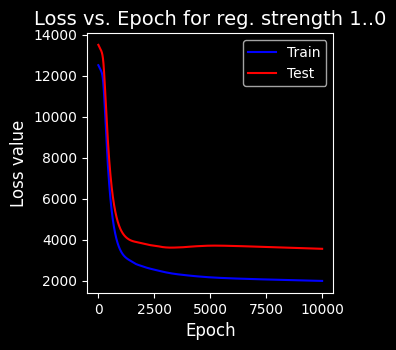

In [21]:
# Plot train and test loss as a function of epoch:
fig, ax = plt.subplots(1, 1, figsize = (4, 4))
fig.tight_layout(pad = 4.0)
ax.plot(loss_train_epoch, 'b', label = 'Train')
ax.plot(loss_test_epoch, 'r', label = 'Test')
ax.set_xlabel('Epoch', fontsize = 12)
ax.set_ylabel('Loss value', fontsize = 12)
ax.legend()
ax.set_title('Loss vs. Epoch for reg. strength 1..0', fontsize = 14);

---

Test performance on test data

---

In [22]:
dlayer1.forward(X_test_transformed)
alayer1.forward(dlayer1.output)
dlayer2.forward(alayer1.output)
ypred = dlayer2.output.flatten()
ytrue = Y_test

---

Define neural network architecture for regression

---

In [23]:
# Define neural network architecture for regression
model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(X_train_transformed.T.shape[1], ), kernel_regularizer = keras.regularizers.l2(l2 = 1.0)),
    layers.Dense(1)
])

---

Compile the neural network

---

In [24]:
# Compile the neural network model
opt = tf.keras.optimizers.Adam(learning_rate = 1e-04)
model.compile(optimizer = opt, loss = 'mean_squared_error')

---

Train the model

---

In [25]:
# Train the model
history = model.fit(X_train_transformed.T, Y_train, epochs = 10000, batch_size = 32, validation_data=(X_test_transformed.T, Y_test))

Epoch 1/10000
12/12 [==============================] - 2s 37ms/step - loss: 29908.4023 - val_loss: 27275.1016
Epoch 2/10000
12/12 [==============================] - 0s 10ms/step - loss: 29902.2852 - val_loss: 27269.8379
Epoch 3/10000
12/12 [==============================] - 0s 9ms/step - loss: 29896.0859 - val_loss: 27264.7168
Epoch 4/10000
12/12 [==============================] - 0s 9ms/step - loss: 29890.0566 - val_loss: 27259.4883
Epoch 5/10000
12/12 [==============================] - 0s 9ms/step - loss: 29883.9180 - val_loss: 27254.4297
Epoch 6/10000
12/12 [==============================] - 0s 10ms/step - loss: 29877.8535 - val_loss: 27249.2754
Epoch 7/10000
12/12 [==============================] - 0s 9ms/step - loss: 29871.6875 - val_loss: 27243.8633
Epoch 8/10000
12/12 [==============================] - 0s 9ms/step - loss: 29865.4785 - val_loss: 27238.8027
Epoch 9/10000
12/12 [==============================] - 0s 8ms/step - loss: 29859.6738 - val_loss: 27233.8184
Epoch 10/10000
1

---

Plot train and test loss as a function of epoch

---

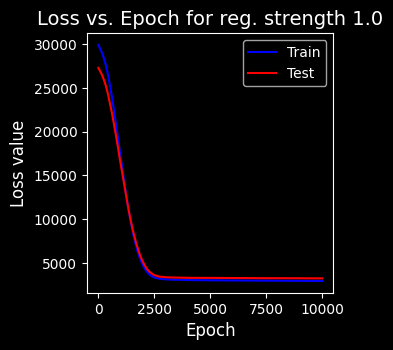

In [26]:
# Plot train and test loss as a function of epoch:
fig, ax = plt.subplots(1, 1, figsize = (4, 4))
fig.tight_layout(pad = 4.0)
ax.plot( history.history['loss'], 'b', label = 'Train')
ax.plot( history.history['val_loss'], 'r', label = 'Test')
ax.set_xlabel('Epoch', fontsize = 12)
ax.set_ylabel('Loss value', fontsize = 12)
ax.legend()
ax.set_title('Loss vs. Epoch for reg. strength 1.0', fontsize = 14);

---

Compare the true and predicted values

---

In [27]:
## Compare the true and predicted values
ypred_TF = model.predict(X_test_transformed.T)
np.column_stack((Y_test, ypred, ypred_TF))

3/3 [==============================] - 1s 3ms/step


array([[ 78.  , 133.97, 115.08],
       [152.  , 109.35, 122.5 ],
       [200.  , 166.  , 184.56],
       [ 59.  ,  69.87,  81.63],
       [311.  , 149.82, 169.72],
       [178.  , 161.93, 189.84],
       [332.  , 164.48, 222.  ],
       [132.  ,  69.28, 118.43],
       [156.  ,  83.43, 150.39],
       [135.  , 148.07, 123.12],
       [220.  , 165.99, 208.51],
       [233.  , 165.93, 196.45],
       [ 91.  ,  69.62,  85.79],
       [ 51.  ,  69.6 ,  77.95],
       [195.  , 165.92, 235.15],
       [109.  , 165.74, 205.91],
       [217.  , 150.36, 175.11],
       [ 94.  , 158.52,  94.5 ],
       [ 89.  ,  69.44, 115.13],
       [111.  , 156.65, 163.86],
       [129.  , 159.44, 187.19],
       [181.  ,  72.74,  84.41],
       [168.  , 163.61, 135.  ],
       [ 97.  , 138.63, 119.41],
       [115.  , 144.76,  86.99],
       [202.  , 165.54, 211.79],
       [ 84.  ,  68.77,  88.55],
       [147.  , 165.73, 169.79],
       [253.  , 127.69, 123.  ],
       [144.  , 151.09, 182.73],
       [26

In [57]:
b = 8 #batch size
nl = 10 #number of nodes n in layer l
probability_dropout = 0.2 #probability of dropout


#Simulate a activated scores matrix
A = np.random.randint(1, 20, (nl, b))
print(A)
print('\n-------------------\n')

# Create a Dropout matrix
D = np.random.rand(A.shape[0], A.shape[1])
print(D)
print('\n-------------------\n')

#Binary dropout matrix
D = D < (1 - probability_dropout)

#Dropout applied Activations matrix
A = (A * D) / (1 - probability_dropout)
print(A)



[[ 8  9  1 15 14  8  1  7]
 [12 10  1  6 10 15  5  3]
 [ 5  2  7 14 13  3 11 19]
 [ 6  1 16  5  7 13  7 16]
 [ 6 19  9 14  6  4 16  5]
 [12  8  2  5  8 19 17  5]
 [ 8 13 13  8 16 10  7 14]
 [14 16 12  6 10  3 17 17]
 [ 9 15 15 15 13 15  5 12]
 [ 8 15  5 19 15 19  2 19]]

-------------------

[[0.49 0.44 0.7  0.6  0.17 0.77 0.27 0.51]
 [0.04 0.33 0.36 0.13 0.08 0.8  0.16 0.25]
 [0.07 0.35 0.17 0.12 0.53 0.04 0.37 0.4 ]
 [0.81 0.72 0.74 0.99 0.97 0.41 0.57 0.6 ]
 [0.1  0.54 0.13 0.96 0.51 0.53 0.25 0.58]
 [0.51 0.65 0.2  0.72 0.48 0.12 0.17 0.49]
 [0.69 0.11 0.75 0.86 0.57 0.38 0.65 0.56]
 [0.47 0.32 0.02 0.65 0.62 0.98 0.86 0.1 ]
 [0.42 0.35 0.06 0.45 0.52 0.82 0.04 0.11]
 [0.06 0.89 0.76 0.53 0.56 0.32 0.86 0.59]]

-------------------

[[10.   11.25  1.25 18.75 17.5  10.    1.25  8.75]
 [15.   12.5   1.25  7.5  12.5  18.75  6.25  3.75]
 [ 6.25  2.5   8.75 17.5  16.25  3.75 13.75 23.75]
 [ 0.    1.25 20.    0.    0.   16.25  8.75 20.  ]
 [ 7.5  23.75 11.25  0.    7.5   5.   20.    6.25]

In [ ]:
# Use house price dataset and compare it with lm in AAPS
# Use dropout as regularization in the neural network model for mnist dataset. 
#